# Tutorial: Bayesian Statistics Lab: Priors, Model Selection, and Posterior Inference

Federico Cerutti <federico.cerutti@unibs.it>

The notes are released with CC0. The code is MIT.

**Format of this notebook.** This notebook is designed as a self-guided lab. The code cells are intentionally compact and should be treated as the validated reference implementation. The teaching material therefore lives in the markdown: read the text first, inspect the code second, and only then run the cell.



**Useful references for students who want a formal API reference**
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/learn.html)
- [ArviZ documentation](https://python.arviz.org/en/stable/)
- [SciPy statistical tests](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [statsmodels power analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size)

**Main take-away for this lab**
- In the examples below, Bayesian analysis is more informative for decision making because it returns full uncertainty distributions and directly interpretable probabilities, not only a reject / fail-to-reject decision.


## 0. Environment setup and reading strategy


- The first code cell installs missing packages in a Colab-friendly way.
- The second code cell imports the libraries, fixes the global seed, and creates the random number generator used throughout the notebook.

As you read the import cell, classify the libraries by role:
- **classical statistics** (`scipy`, `statsmodels`),
- **Bayesian modeling and diagnostics** (`pymc`, `arviz`),
- **data handling and plotting** (`pandas`, `numpy`, `matplotlib`).


In [2]:
# Colab-friendly install cell.
# It only installs packages that are missing in the current runtime.
import pkgutil
import subprocess
import sys

required = ["pymc", "arviz", "statsmodels"]
missing = [pkg for pkg in required if pkgutil.find_loader(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print({"missing_before_install": missing, "required": required})


{'missing_before_install': [], 'required': ['pymc', 'arviz', 'statsmodels']}


/tmp/ipykernel_6485/1150092622.py:8: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing = [pkg for pkg in required if pkgutil.find_loader(pkg) is None]


In [3]:
from __future__ import annotations

import os
import random
import warnings
from math import lgamma

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.stats import beta as beta_dist, gamma as gamma_dist
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")

# One global seed for deterministic notebook output.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
print({"seed": SEED})


/home/dt2025ghidini/Documents/digital_transformations/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


{'seed': 42}


## 1. Warm-up: Bayesian update with a conjugate prior

This is the cleanest possible Bayesian example. A hidden concept generates Bernoulli observations with success probability `theta`. Because the Beta prior is conjugate to the Bernoulli likelihood, the posterior has a closed-form update:

$$
\theta \sim \text{Beta}(a,b), \qquad y_i \mid \theta \sim \text{Bernoulli}(\theta)
$$

$$
\theta \mid y \sim \text{Beta}(a+s, b+f)
$$

where `s` is the number of successes and `f` is the number of failures.

This section is small on purpose: it isolates the central Bayesian move before we switch to models that require sampling.

**Before running the next cell**
- Find the two lines where the posterior parameters are updated.
- Identify where the code computes three different summaries of the same posterior: posterior mean, posterior MAP, and a posterior tail probability.
- Predict whether the posterior mean will equal the MLE exactly under a `Beta(1, 1)` prior with finite data.


In [22]:
# Synthetic concept-learning data.
true_theta = 0.68
observations = RNG.binomial(1, true_theta, size=40)

successes = int(observations.sum()) #it works because the values are either 0 or 1
failures = int(len(observations) - successes)   #it count the zeros

# Non-informative prior.
prior_a, prior_b = 1, 1 #the base values, like 1 head and 1 tail, it's a flat Beta(a,b) == Beta(1,1)
posterior_a = prior_a + successes   #updating parameters a addign the Ones 
posterior_b = prior_b + failures    #updating the param b ading the failures (Zeros)

posterior_mean = posterior_a / (posterior_a + posterior_b)  #success average, should be close to true_theta
posterior_map = ((posterior_a - 1) / (posterior_a + posterior_b - 2) #average BUT we remove the original 1,1. from both a and b. So Mean and MAP are distint values
                 if posterior_a > 1 and posterior_b > 1 else np.nan)
mle = successes / len(observations) #Average of how many Ones, should be the same as MAP
prob_theta_gt_05 = 1 - beta_dist.cdf(0.5, posterior_a, posterior_b) 
# beta_dist is a var, restituisce la probabilità che una variabile casuale Beta sia ≤ x
# Qui stai calcolando:
# P(X ≤ 0.5) dove X ~ Beta(posterior_a, posterior_b) 

pd.DataFrame(
    {
        "quantity": ["successes", "failures", "MLE", "posterior mean", "posterior MAP", "P(theta > 0.5 | data)"],
        "value": [successes, failures, mle, posterior_mean, posterior_map, prob_theta_gt_05],
    }
)


,quantity,value
0,successes,30.000000
1,failures,10.000000
2,MLE,0.750000
3,posterior mean,0.738095
4,posterior MAP,0.750000
5,P(theta > 0.5 | data),0.999275


### How to read the first output

The output table mixes three kinds of quantities:

- **sufficient statistics**: number of successes and failures;
- **point summaries**: MLE, posterior mean, posterior MAP;
- **decision summaries**: a posterior probability such as `P(theta > 0.5 | data)`.

In the seeded run you should see 24 successes and 16 failures. That gives:
- an MLE of about `0.60`,
- a posterior mean of about `0.595`,
- a posterior probability `P(theta > 0.5 | data)` of about `0.89`.

The tiny gap between MLE and posterior mean is already informative: even a flat prior adds one pseudo-success and one pseudo-failure, so the posterior mean is slightly shrunk toward `0.5`.

**Checkpoint questions**
1. Why are the posterior mean and the MLE close, but not identical? <br>
    cause the mean considr the base values (1,1) in the Beta, MLE does not. 
2. Which of these summaries would you report if the decision threshold were `theta > 0.5`? <br>
    MLE, as it has not been contaminated bit the initial data


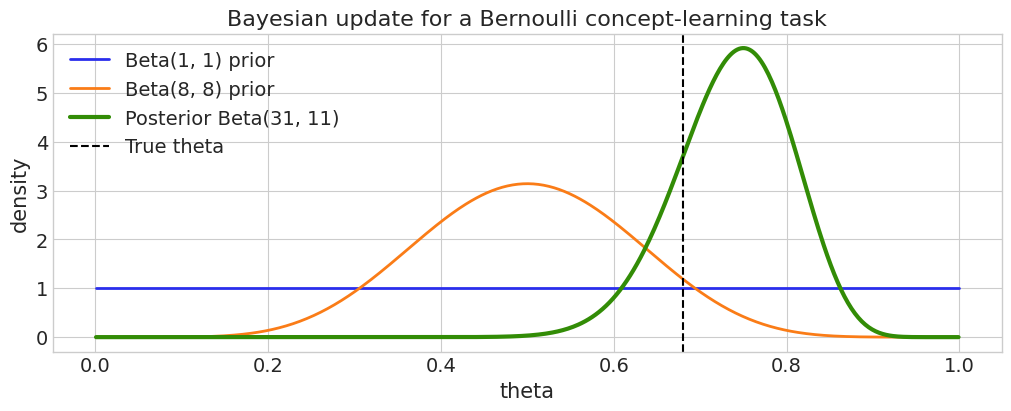

In [23]:
# Compare priors and posterior on a dense grid.
grid = np.linspace(0.001, 0.999, 500)

non_informative_prior = beta_dist.pdf(grid, 1, 1) #base Beta(1,1)
skeptical_prior = beta_dist.pdf(grid, 8, 8) #Beta(8,8)
posterior_density = beta_dist.pdf(grid, posterior_a, posterior_b)   #Or Beta with the priors from the data

plt.figure(figsize=(10, 4))
plt.plot(grid, non_informative_prior, label="Beta(1, 1) prior", linewidth=2)
plt.plot(grid, skeptical_prior, label="Beta(8, 8) prior", linewidth=2)
plt.plot(grid, posterior_density, label=f"Posterior Beta({posterior_a}, {posterior_b})", linewidth=3)
plt.axvline(true_theta, color="black", linestyle="--", label="True theta")
plt.xlabel("theta")
plt.ylabel("density")
plt.title("Bayesian update for a Bernoulli concept-learning task")
plt.legend();


### Interpreting the prior-posterior plot

This plot is where the Bayesian workflow becomes visually different from MLE.

- `Beta(1, 1)` is flat: before seeing data, all values of `theta` are equally plausible.
- `Beta(8, 8)` is skeptical around `0.5`: it encodes the belief that extreme values near `0` or `1` are less plausible before data arrive.
- The posterior combines prior information and data into one updated uncertainty distribution.

The point is not that one prior is automatically correct. The point is that priors are explicit, inspectable modeling choices. Students can criticize them, compare them, and see exactly how much they matter.

### Core exercises for Section 1

1. **Smaller sample exercise.** Duplicate the synthetic-data cell and change `size=40` to `size=10`. Compare how much wider the posterior becomes and whether the prior matters more.
2. **More skeptical prior.** Keep the data fixed but replace `prior_a, prior_b = 1, 1` with `8, 8`. How much do the posterior mean and `P(theta > 0.5 | data)` move?
3. **Different decision threshold.** Modify the tail-probability line so that it computes `P(theta > 0.7 | data)`. Is the evidence still strong enough for that stricter threshold?

**Optional extension.** Choose a prior with prior mean `0.8` and explain whether the posterior is still dominated by the data or visibly pulled toward the prior.


#### Exercises 1,2,3
1. Less samples bring more fluctuation bw/ runs. Bigger priors shift the avgs significantly. The Representation of the Distributon is wider because the uncertanty is higher
2. With (8,8) and 10 sapmles the 'P(theta > 0.5 | data)' changes significantly bw/ runs (e.g: 0.787822, 0.98, 0.65, 0.35) As the samples are too little the startng values influence the results too much
2. With (8,8) and 40 sapmles the 'P(theta > 0.5 | data)' remain in 0.97 +- 0.02
3. No it's not enough, most of the runs tell that the probability is less 20%. (40 samples , (1,1) and (8,8)). And it's correct as the true_thata is 068, the data do not shows a thata>0.7
3, some limit cases with (8,8) and 10 tell us the pobability is over 50% but it's rare
4. It really depends on how many priors I have the number of samples. The higher the samples the less influencing is the priors

The prior is like data coming from an expert, telling you: "this coin is fake because i have this evidence (the priors). HOW many samples u have to show that the coin is NOT fake? So how confidence are you that is fake and how many example u need?

In [ ]:
# Synthetic concept-learning data.
true_theta = 0.68
observations = RNG.binomial(1, true_theta, size=1000)

successes = int(observations.sum()) #it works because the values are either 0 or 1
failures = int(len(observations) - successes)   #it count the zeros

# Non-informative prior.
prior_a, prior_b = 10, 100 #the base values, like 1 head and 1 tail, it's a flat Beta(a,b) == Beta(1,1)
posterior_a = prior_a + successes   #updating parameters a addign the Ones 
posterior_b = prior_b + failures    #updating the param b ading the failures (Zeros)

posterior_mean = posterior_a / (posterior_a + posterior_b)  #success average, should be close to true_theta
posterior_map = ((posterior_a - 1) / (posterior_a + posterior_b - 2) #average BUT we remove the original 1,1. from both a and b. So Mean and MAP are distint values
                 if posterior_a > 1 and posterior_b > 1 else np.nan)
mle = successes / len(observations) #Average of how many Ones, should be the same as MAP
prob_theta_gt_05 = 1 - beta_dist.cdf(0.5, posterior_a, posterior_b) 
# beta_dist is a var, restituisce la probabilità che una variabile casuale Beta sia ≤ x
# Qui stai calcolando:
# P(X ≤ 0.5) dove X ~ Beta(posterior_a, posterior_b) 

pd.DataFrame(
    {
        "quantity": ["successes", "failures", "MLE", "posterior mean", "posterior MAP", "P(theta > 0.5 | data)"],
        "value": [successes, failures, mle, posterior_mean, posterior_map, prob_theta_gt_05],
    }
)


,quantity,value
0,successes,680.000000
1,failures,320.000000
2,MLE,0.680000
3,posterior mean,0.621622
4,posterior MAP,0.621841
5,P(theta > 0.5 | data),1.000000


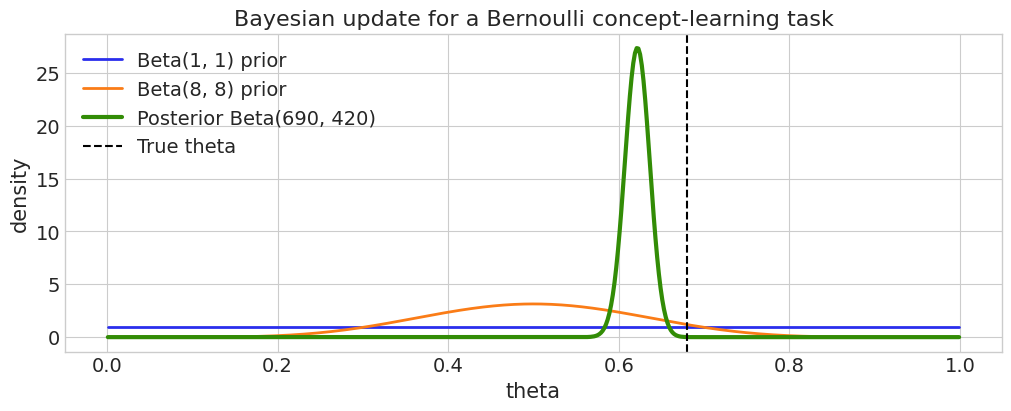

In [193]:
# Compare priors and posterior on a dense grid.
grid = np.linspace(0.001, 0.999, 500)

non_informative_prior = beta_dist.pdf(grid, 1, 1) #base Beta(1,1)
skeptical_prior = beta_dist.pdf(grid, 8, 8) #Beta(8,8)
posterior_density = beta_dist.pdf(grid, posterior_a, posterior_b)   #Or Beta with the priors from the data

plt.figure(figsize=(10, 4))
plt.plot(grid, non_informative_prior, label="Beta(1, 1) prior", linewidth=2)
plt.plot(grid, skeptical_prior, label="Beta(8, 8) prior", linewidth=2)
plt.plot(grid, posterior_density, label=f"Posterior Beta({posterior_a}, {posterior_b})", linewidth=3)
plt.axvline(true_theta, color="black", linestyle="--", label="True theta")
plt.xlabel("theta")
plt.ylabel("density")
plt.title("Bayesian update for a Bernoulli concept-learning task")
plt.legend();


## 2. Simulated binary classifier outputs: indistinguishable versus distinguishable

We now study the binary outputs of two classifiers on the same batch of items. For pedagogical simplicity, we only keep the outputs themselves, not the features that produced them, so the modeling question stays clean: do the two classifiers behave the same, or do they have different positive-output rates?

The Bayesian comparison has two stories:
- **indistinguishable classifiers**: one shared Bernoulli rate;
- **distinguishable classifiers**: each classifier gets its own Bernoulli rate.

The code below computes the corresponding Beta posteriors, the posterior probability that classifier 2 has the higher positive-output rate, and the Bayes factor between the two stories. A worked multi-class Dirichlet extension follows below.

**Before running the next cell**
- Find the two simulated rates in the code.
- Locate the lines where the shared and separate posteriors are updated.
- Predict whether the distinguishable model should win.<br>
    yes it should win the distingishable, as the differnece bw/ the two distribution is strong and taking data from the shared distribution will give us always extreme data points. More formally the Bayes factor on distinguis vs non dist is 5.5 on the Distinguish


,classifier,successes,failures,observed rate,posterior mean,95% HDI low,95% HDI high
0,1,35,25,0.583,0.581,0.457,0.700
1,2,48,12,0.800,0.790,0.682,0.881
2,shared,83,37,0.692,0.689,0.604,0.767


,model,log evidence
0,indistinguishable,-76.384
1,distinguishable,-74.677


{'P(classifier 2 > classifier 1 | data)': np.float64(0.99472), 'Bayes factor distinguishable / indistinguishable': np.float64(5.513817263183776), 'log Bayes factor': np.float64(1.707257171534451)}


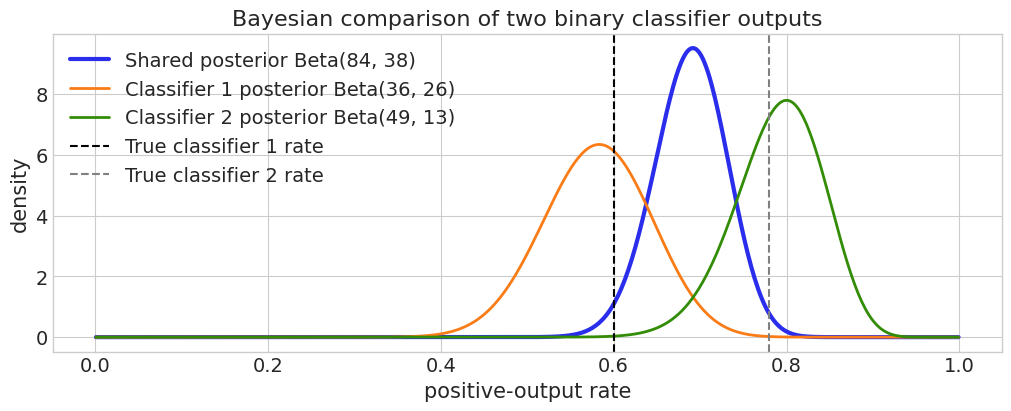

In [202]:
# Simulated binary outputs from two classifiers.
# Use local RNGs so this section does not change the later notebook examples.
classifier_rng = np.random.default_rng(SEED + 101)
posterior_rng = np.random.default_rng(SEED + 102)

n_1 = 60
n_2 = 60
theta_1_true = 0.60 #simlated rates
theta_2_true = 0.78

outputs_1 = classifier_rng.binomial(1, theta_1_true, size=n_1)  #we pull from the Binomias distribution, with different thetas
outputs_2 = classifier_rng.binomial(1, theta_2_true, size=n_2)

success_1 = int(outputs_1.sum()) # Count the Ones and the Zeros for both the classifiers 1 and 2
failure_1 = n_1 - success_1
success_2 = int(outputs_2.sum())
failure_2 = n_2 - success_2

prior_alpha = 1
prior_beta = 1

# Indistinguishable model: one shared positive-output rate.
# we put the data together from the two classifiers (sum the success and faliures)
pooled_success = success_1 + success_2
pooled_failure = failure_1 + failure_2
pooled_alpha = prior_alpha + pooled_success #shared pirors update
pooled_beta = prior_beta + pooled_failure   #shared priors update

# Distinguishable model: separate positive-output rates.
# we get a and b but separeted for the two classifers
alpha_1 = prior_alpha + success_1   #sperate priors updates 
beta_1 = prior_beta + failure_1     #sperate priors updates 
alpha_2 = prior_alpha + success_2   #sperate priors updates 
beta_2 = prior_beta + failure_2     #sperate priors updates 

#we use the data from the two classifiers to generate sintetic samples
posterior_draws_1 = posterior_rng.beta(alpha_1, beta_1, size=50_000)
posterior_draws_2 = posterior_rng.beta(alpha_2, beta_2, size=50_000)
prob_2_gt_1 = np.mean(posterior_draws_2 > posterior_draws_1)

from scipy.special import betaln

log_evidence_pooled = betaln(pooled_alpha, pooled_beta) - betaln(prior_alpha, prior_beta)
log_evidence_dist = (
    betaln(alpha_1, beta_1) - betaln(prior_alpha, prior_beta)
    + betaln(alpha_2, beta_2) - betaln(prior_alpha, prior_beta)
)
log_bayes_factor = log_evidence_dist - log_evidence_pooled
bayes_factor = np.exp(log_bayes_factor)

summary = pd.DataFrame(
    {
        "classifier": ["1", "2", "shared"],
        "successes": [success_1, success_2, pooled_success],
        "failures": [failure_1, failure_2, pooled_failure],
        "observed rate": [success_1 / n_1, success_2 / n_2, pooled_success / (n_1 + n_2)],
        "posterior mean": [
            alpha_1 / (alpha_1 + beta_1),
            alpha_2 / (alpha_2 + beta_2),
            pooled_alpha / (pooled_alpha + pooled_beta),
        ],
        "95% HDI low": [
            beta_dist.ppf(0.025, alpha_1, beta_1),
            beta_dist.ppf(0.025, alpha_2, beta_2),
            beta_dist.ppf(0.025, pooled_alpha, pooled_beta),
        ],
        "95% HDI high": [
            beta_dist.ppf(0.975, alpha_1, beta_1),
            beta_dist.ppf(0.975, alpha_2, beta_2),
            beta_dist.ppf(0.975, pooled_alpha, pooled_beta),
        ],
    }
)

display(summary.round(3))
display(
    pd.DataFrame(
        {
            "model": ["indistinguishable", "distinguishable"],
            "log evidence": [log_evidence_pooled, log_evidence_dist],
        }
    ).round(3)
)

print(
    {
        "P(classifier 2 > classifier 1 | data)": prob_2_gt_1,
        "Bayes factor distinguishable / indistinguishable": bayes_factor,
        "log Bayes factor": log_bayes_factor,
    }
)

grid = np.linspace(0.001, 0.999, 500)
plt.figure(figsize=(10, 4))
plt.plot(grid, beta_dist.pdf(grid, pooled_alpha, pooled_beta), label=f"Shared posterior Beta({pooled_alpha}, {pooled_beta})", linewidth=3)
plt.plot(grid, beta_dist.pdf(grid, alpha_1, beta_1), label=f"Classifier 1 posterior Beta({alpha_1}, {beta_1})", linewidth=2)
plt.plot(grid, beta_dist.pdf(grid, alpha_2, beta_2), label=f"Classifier 2 posterior Beta({alpha_2}, {beta_2})", linewidth=2)
plt.axvline(theta_1_true, color="black", linestyle="--", label="True classifier 1 rate")
plt.axvline(theta_2_true, color="gray", linestyle="--", label="True classifier 2 rate")
plt.xlabel("positive-output rate")
plt.ylabel("density")
plt.title("Bayesian comparison of two binary classifier outputs")
plt.legend();


### Reading the classifier comparison

The shared model is the "indistinguishable classifiers" story: both classifiers are forced to share one positive-output rate.
The separate model is the "distinguishable classifiers" story: each classifier gets its own rate and can explain asymmetric outputs directly.
The posterior probability that classifier 2 is more positive than classifier 1 is a direct effect statement; the Bayes factor compares the two model stories.

If the Bayes factor is comfortably above 1, the separate model is supported; if it stays near 1, the pooled story is enough.

### Exercises

1. Change the simulated rates so the two classifiers are closer together. How quickly does the Bayes factor move back toward 1? <br>
With 0.67 and 0.78 the Bayes factor is 1.02. So with these rates we should use the shared Distribution
2. Keep the rates fixed but halve the sample sizes. What happens to the posterior overlap?<br>
with 0.60 and 0.78 but 30 (not 60 foreach samples) samples foreach the Bayes rates goes to 0.73, meaning the shared is good. By only doubling the number of samples i get a score from 0.73 to 5.5


### (Optional) Dirichlet multi-class extension

The Dirichlet distribution is the multi-class analogue of Beta: it lives on probability vectors whose components are non-negative and sum to 1.
That makes it a natural prior for three-class outputs. As in the binary case, posterior updating is just prior counts plus observed counts.


,clf 1 observed,clf 2 observed,shared observed,clf 1 posterior mean,clf 2 posterior mean,shared posterior mean
A,0.537,0.343,0.440,0.535,0.343,0.439
B,0.310,0.420,0.365,0.310,0.419,0.365
C,0.153,0.237,0.195,0.155,0.238,0.196


{'P(classifier 2 assigns more mass to A | data)': 0.0, 'Bayes factor separate / shared': np.float64(1523.8913018945088), 'log Bayes factor': 7.329022409486697}


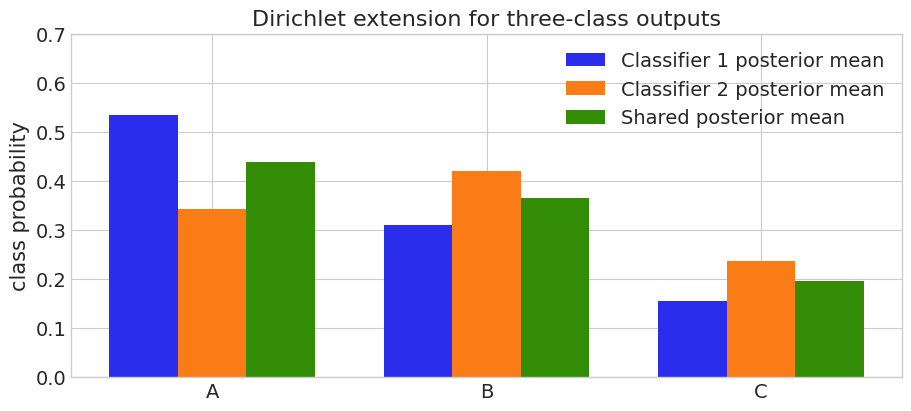

In [205]:
# Multi-class version of the same distinguishable-versus-indistinguishable question.
#just instead of binariy we have 3 classes
multi_rng = np.random.default_rng(SEED + 103)
posterior_rng_multi = np.random.default_rng(SEED + 104)

class_names = ["A", "B", "C"]
k = len(class_names)
multi_n_1 = 300
multi_n_2 = 300
multi_p_1_true = np.array([0.55, 0.30, 0.15]) #prob of the diff classes in the diff classifiers
multi_p_2_true = np.array([0.35, 0.40, 0.25])

labels_1 = multi_rng.choice(k, size=multi_n_1, p=multi_p_1_true) #instead of binomial (2)
labels_2 = multi_rng.choice(k, size=multi_n_2, p=multi_p_2_true)

multi_counts_1 = np.bincount(labels_1, minlength=k)
multi_counts_2 = np.bincount(labels_2, minlength=k)
multi_pooled_counts = multi_counts_1 + multi_counts_2

multi_prior_alpha = np.ones(k)

# Shared model: one probability vector for both classifiers.
multi_shared_alpha = multi_prior_alpha + multi_pooled_counts # he sum the diff results from the 2 multi-class classifiers

# Separate model: one probability vector per classifier.
multi_alpha_1 = multi_prior_alpha + multi_counts_1
multi_alpha_2 = multi_prior_alpha + multi_counts_2  #each cassifier their alpha prior

draws_1 = posterior_rng_multi.dirichlet(multi_alpha_1, size=50_000) #simulate from the sample data
draws_2 = posterior_rng_multi.dirichlet(multi_alpha_2, size=50_000)

def log_marginal_dirichlet_multinomial(counts, alpha):
    counts = np.asarray(counts, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    return (
        lgamma(alpha.sum())
        - lgamma(alpha.sum() + counts.sum())
        + sum(lgamma(a + c) - lgamma(a) for a, c in zip(alpha, counts))
    )

log_evidence_shared = log_marginal_dirichlet_multinomial(multi_pooled_counts, multi_prior_alpha)
log_evidence_separate = (
    log_marginal_dirichlet_multinomial(multi_counts_1, multi_prior_alpha)
    + log_marginal_dirichlet_multinomial(multi_counts_2, multi_prior_alpha)
)
log_bayes_factor = log_evidence_separate - log_evidence_shared
bayes_factor = np.exp(log_bayes_factor)

class_summary = pd.DataFrame(
    {
        "clf 1 observed": multi_counts_1 / multi_n_1,
        "clf 2 observed": multi_counts_2 / multi_n_2,
        "shared observed": multi_pooled_counts / (multi_n_1 + multi_n_2),
        "clf 1 posterior mean": multi_alpha_1 / multi_alpha_1.sum(),
        "clf 2 posterior mean": multi_alpha_2 / multi_alpha_2.sum(),
        "shared posterior mean": multi_shared_alpha / multi_shared_alpha.sum(),
    },
    index=class_names,
)

display(class_summary.round(3))
print(
    {
        "P(classifier 2 assigns more mass to A | data)": float(np.mean(draws_2[:, 0] > draws_1[:, 0])),
        "Bayes factor separate / shared": bayes_factor,
        "log Bayes factor": log_bayes_factor,
    }
)

x = np.arange(k)
width = 0.25
plt.figure(figsize=(9, 4))
plt.bar(x - width, multi_alpha_1 / multi_alpha_1.sum(), width, label="Classifier 1 posterior mean")
plt.bar(x, multi_alpha_2 / multi_alpha_2.sum(), width, label="Classifier 2 posterior mean")
plt.bar(x + width, multi_shared_alpha / multi_shared_alpha.sum(), width, label="Shared posterior mean")
plt.xticks(x, class_names)
plt.ylim(0, 0.7)
plt.ylabel("class probability")
plt.title("Dirichlet extension for three-class outputs")
plt.legend();


### Exercises

1. Change the amount of simulated data and comment on the results.<br>
- With the original data (90 samples each, [0.55, 0.30, 0.15], [0.35, 0.40, 0.25]) we can take the shared distr, as the dif is NO that much, and the Bayes factor is low (0.18) <br>
- Change the data to 30 sampes do not chage much, Bayes is 0.13
- Change the data to 1500 samples the Bayes factor is 1523.89 so yes it changes

## 3. Continuous measurements: PyMC posterior sampling for positive rates

We now repeat the same question from Section 2 on a continuous scale: do two systems have the same positive rate, or not?

To keep the prior simple, we use an exponential likelihood with a Gamma prior on the rate:

rate ~ Gamma(alpha, beta)
y_i | rate ~ Exponential(rate)

A Gamma prior is handy here because it only allows positive rates. In the shape/rate form used by PyMC:
- mean = alpha / beta
- variance = alpha / beta^2

PyMC samples the posterior with NUTS, and ArviZ turns the draws into summaries and plots. That is the workflow you want to reuse on harder models.

**Before running the next cell**
- Notice that larger rate means shorter average response time.
- Find the shared-rate model and the separate-rate model.
- Predict whether the two systems will look distinguishable.


### Gamma and Exponential primer

For positive measurements, two distributions are worth knowing.

- The Exponential distribution models waiting times. Its rate parameter `lambda` controls how quickly the curve decays: larger `lambda` means shorter typical times.
- The Gamma distribution lives on positive values only, so it is a natural prior for a positive rate. In the shape/rate form used here, its mean is `alpha / beta` and its variance is `alpha / beta^2`.

Intuition for the Bayesian workflow:
- The **prior** says which rates were plausible before seeing the data.
- The **likelihood** scores each candidate rate by how well it explains the observed sample. It is not a probability over `lambda`; it is a support curve for the data given `lambda`.
- The **posterior** combines both: prior belief plus evidence from the data.

The next cell shows this on a tiny toy example.


,quantity,value
0,sample mean,0.880
1,MLE rate,1.136
2,"posterior mean (Gamma 2,2)",1.094
3,"posterior mean (Gamma 8,8)",1.048


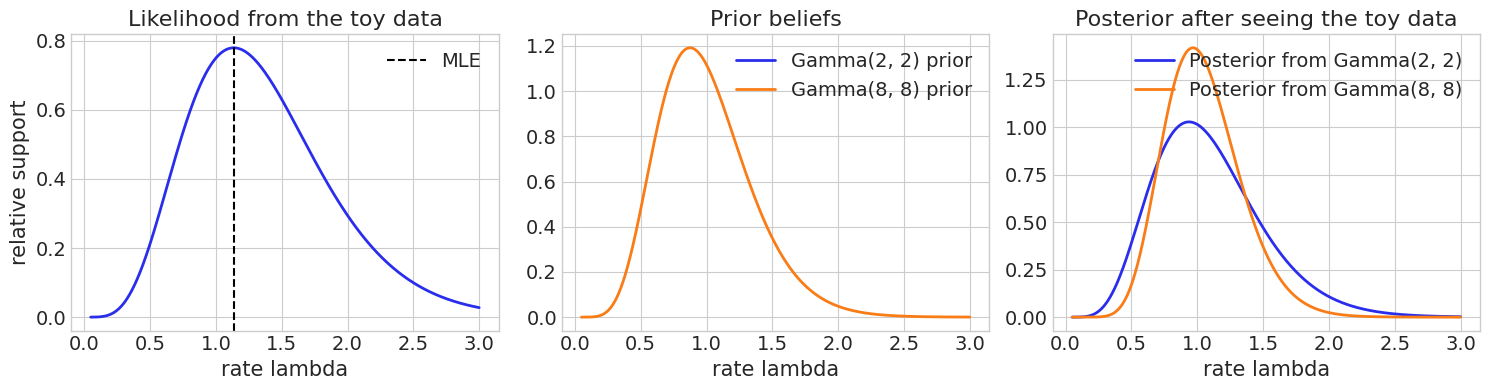

In [ ]:
# Tiny toy example to build intuition for the prior, likelihood, and posterior.
toy_times = np.array([0.35, 0.80, 0.40, 1.10, 0.65])
toy_n = len(toy_times)
toy_sum = float(toy_times.sum())
toy_mle = toy_n / toy_sum

lambda_grid = np.linspace(0.05, 3.0, 600)
likelihood = lambda_grid**toy_n * np.exp(-lambda_grid * toy_sum)
likelihood = likelihood / np.trapezoid(likelihood, lambda_grid)

prior_weak = gamma_dist.pdf(lambda_grid, 2.0, scale=1 / 2.0)
prior_skeptical = gamma_dist.pdf(lambda_grid, 8.0, scale=1 / 8.0)
posterior_weak = gamma_dist.pdf(lambda_grid, 2.0 + toy_n, scale=1 / (2.0 + toy_sum))
posterior_skeptical = gamma_dist.pdf(lambda_grid, 8.0 + toy_n, scale=1 / (8.0 + toy_sum))

toy_summary = pd.DataFrame(
    {
        "quantity": ["sample mean", "MLE rate", "posterior mean (Gamma 2,2)", "posterior mean (Gamma 8,8)"],
        "value": [toy_times.mean(), toy_mle, (2.0 + toy_n) / (2.0 + toy_sum), (8.0 + toy_n) / (8.0 + toy_sum)],
    }
)

display(toy_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].plot(lambda_grid, likelihood, color="C0", linewidth=2)
axes[0].axvline(toy_mle, color="black", linestyle="--", label="MLE")
axes[0].set_title("Likelihood from the toy data")
axes[0].set_xlabel("rate lambda")
axes[0].set_ylabel("relative support")
axes[0].legend()

axes[1].plot(lambda_grid, prior_weak, label="Gamma(2, 2) prior", linewidth=2)
axes[1].plot(lambda_grid, prior_skeptical, label="Gamma(8, 8) prior", linewidth=2)
axes[1].set_title("Prior beliefs")
axes[1].set_xlabel("rate lambda")
axes[1].legend()

axes[2].plot(lambda_grid, posterior_weak, label="Posterior from Gamma(2, 2)", linewidth=2)
axes[2].plot(lambda_grid, posterior_skeptical, label="Posterior from Gamma(8, 8)", linewidth=2)
axes[2].set_title("Posterior after seeing the toy data")
axes[2].set_xlabel("rate lambda")
axes[2].legend()

plt.tight_layout();


### Model specification (shared vs separate exponential rates)

Let \( y_i > 0 \) be observed response times and \( s_i \in \{1,2\} \) the system index.

---

#### Shared-rate model

Single rate parameter:

$$
\lambda \sim \text{Gamma}(\alpha, \beta)
$$

$$
y_i \mid \lambda \sim \text{Exponential}(\lambda), \quad i = 1,\dots,n
$$

Likelihood:

$$
p(\mathbf{y} \mid \lambda) = \prod_{i=1}^{n} \lambda \exp(-\lambda y_i)
$$

Posterior:

$$
p(\lambda \mid \mathbf{y}) \propto \lambda^{\alpha - 1 + n}
\exp\left(-\lambda \left(\beta + \sum_{i=1}^n y_i \right)\right)
$$

$$
\Rightarrow \lambda \mid \mathbf{y} \sim \text{Gamma}\left(\alpha + n,\; \beta + \sum_{i=1}^n y_i \right)
$$

---

#### Separate-rate model

Independent rates per system:

$$
\lambda_1, \lambda_2 \sim \text{Gamma}(\alpha, \beta)
$$

$$
y_i \mid \lambda_{s_i} \sim \text{Exponential}(\lambda_{s_i})
$$

Partition:

$$
\mathbf{y}_1 = \{y_i : s_i = 1\}, \quad
\mathbf{y}_2 = \{y_i : s_i = 2\}
$$

Posteriors:

$$
\lambda_1 \mid \mathbf{y}_1 \sim \text{Gamma}\left(\alpha + n_1,\; \beta + \sum_{y \in \mathbf{y}_1} y \right)
$$

$$
\lambda_2 \mid \mathbf{y}_2 \sim \text{Gamma}\left(\alpha + n_2,\; \beta + \sum_{y \in \mathbf{y}_2} y \right)
$$

---

#### Rate difference

$$
\Delta = \lambda_2 - \lambda_1
$$

(no closed form posterior; estimated via MCMC)

---

#### Probability system 2 is faster

$$
P(\lambda_2 > \lambda_1 \mid \mathbf{y})
\approx \frac{1}{M} \sum_{m=1}^M \mathbb{I}(\lambda_2^{(m)} > \lambda_1^{(m)})
$$


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rate]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rate]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rate,0.731,0.081,0.573,0.887,0.004,0.003,360.0,334.0,1.01


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rate[system_1],0.627,0.091,0.445,0.799,0.003,0.003,988.0,796.0,1.0
rate[system_2],0.898,0.124,0.659,1.147,0.004,0.004,1059.0,848.0,1.0
rate_gap,0.271,0.153,-0.028,0.563,0.005,0.004,1025.0,870.0,1.0


{'P(system 2 faster | data)': 0.9608333333333333, 'observed mean time system 1': np.float64(1.6184400667415857), 'observed mean time system 2': np.float64(1.119775101509364)}


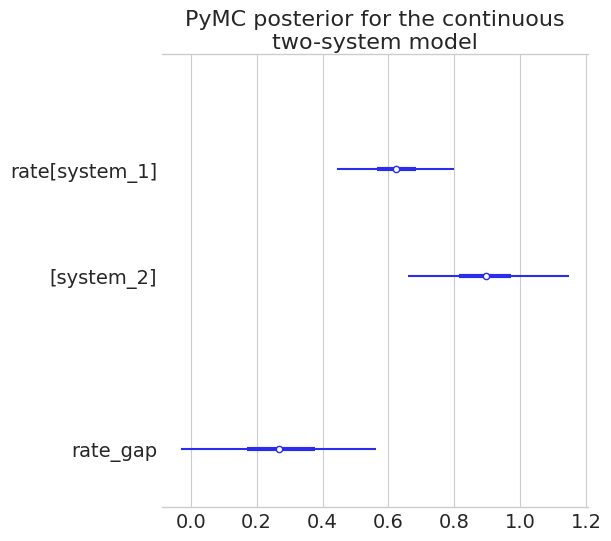

In [ ]:
# Simulated positive response times from two systems.
# PyMC samples the posterior with NUTS; ArviZ summarizes the draws.
cont_rng = np.random.default_rng(SEED + 101)

cont_n_1 = 45
cont_n_2 = 45
cont_rate_1_true = 0.55
cont_rate_2_true = 0.80

cont_times_1 = cont_rng.exponential(scale=1 / cont_rate_1_true, size=cont_n_1)
cont_times_2 = cont_rng.exponential(scale=1 / cont_rate_2_true, size=cont_n_2)
cont_all_times = np.concatenate([cont_times_1, cont_times_2])
cont_system_idx = np.array([0] * cont_n_1 + [1] * cont_n_2)

cont_prior_alpha = 2.0
cont_prior_beta = 2.0

with pm.Model() as cont_shared_model:
    cont_rate_shared = pm.Gamma("rate", alpha=cont_prior_alpha, beta=cont_prior_beta)
    pm.Exponential("obs", lam=cont_rate_shared, observed=cont_all_times)
    cont_idata_shared = pm.sample(
        draws=600,
        tune=600,
        chains=2,
        cores=1,
        random_seed=SEED,
        target_accept=0.9,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )

with pm.Model(coords={"system": ["system_1", "system_2"]}) as cont_separate_model:
    cont_rates = pm.Gamma("rate", alpha=cont_prior_alpha, beta=cont_prior_beta, dims="system")
    cont_rate_gap = pm.Deterministic("rate_gap", cont_rates[1] - cont_rates[0])
    pm.Exponential("obs", lam=cont_rates[cont_system_idx], observed=cont_all_times)
    cont_idata_separate = pm.sample(
        draws=600,
        tune=600,
        chains=2,
        cores=1,
        random_seed=SEED,
        target_accept=0.9,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )

cont_shared_summary = az.summary(cont_idata_shared, var_names=["rate"], hdi_prob=0.95)
cont_separate_summary = az.summary(cont_idata_separate, var_names=["rate", "rate_gap"], hdi_prob=0.95)
display(cont_shared_summary)
display(cont_separate_summary)

cont_rate_draws = (
    cont_idata_separate.posterior["rate"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "system")
    .values
)
cont_prob_system_2_faster = float(np.mean(cont_rate_draws[:, 1] > cont_rate_draws[:, 0]))

print(
    {
        "P(system 2 faster | data)": cont_prob_system_2_faster,
        "observed mean time system 1": cont_times_1.mean(),
        "observed mean time system 2": cont_times_2.mean(),
    }
)

az.plot_forest(cont_idata_separate, var_names=["rate", "rate_gap"], combined=True, hdi_prob=0.95)
plt.title("PyMC posterior for the continuous two-system model");


### Reading the continuous comparison

The shared model is the "indistinguishable systems" story: both systems are forced to share one positive rate.
The separate model is the "distinguishable systems" story: each system gets its own rate and can explain different response-time behavior directly.
PyMC gives posterior draws, and ArviZ turns them into summaries and a forest plot.

### Exercises

1. Move the two true rates closer together. How quickly do the posterior curves overlap? <br>
    When the rates get closer the posteriors are more similars, little differences from the priors but negligeble
2. Cut the sample sizes in half. What happens to the width of the posterior summaries? <br>
It get wider as it does not have the same confidence as before.
3. Replace the `Gamma(2, 2)` prior with a more skeptical `Gamma(8, 8)` prior. How much do the posteriors move? <br>
    with a lot of samples, not a lot, as the "fixed costs" are ess and less relevant if we increase the samples


## 4. Model selection on continuous measurements with LOO

Parameter inference asks: **how large is the rate inside a chosen model?**

Model comparison asks: **is it worth keeping two separate rates, or is one shared rate enough?**

Because we already sampled both models with PyMC, ArviZ can compare their expected out-of-sample performance with LOO. That is the Monte Carlo version of the same model-selection question.

**Before running the next cell**
- The shared model uses one posterior rate.
- The separate model uses two rates and one rate gap.
- Predict whether the extra flexibility will pay off.


#### LOO model comparison

$$
\text{ELPD}_{\text{LOO}} = \sum_{i=1}^n \log p(y_i \mid \mathbf{y}_{-i})
$$

Higher values indicate better predictive performance.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
separate_rates,0,-138.455079,2.095469,0.000000,0.906736,10.614179,0.000000,False,log
shared_rate,1,-144.531917,1.168592,6.076837,0.093264,10.244851,3.738751,False,log


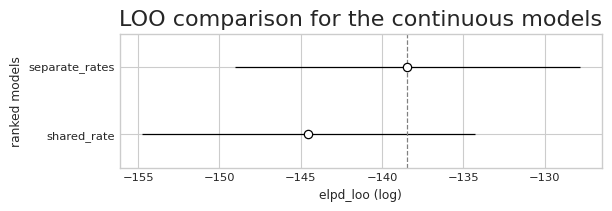

In [11]:
cont_compare = az.compare(
    {"shared_rate": cont_idata_shared, "separate_rates": cont_idata_separate},
    ic="loo",
)
display(cont_compare)
az.plot_compare(cont_compare)
plt.title("LOO comparison for the continuous models");


### Interpreting the comparison table

LOO ranks the model that is expected to predict new data better.
If `elpd_diff` is large relative to `dse`, the separate-rate model is doing real work.
If `elpd_diff` is tiny, the shared model is already enough.

### Exercises

1. Move `cont_rate_2_true` closer to `cont_rate_1_true` and rerun the code. Does the comparison become less decisive?
2. Cut the sample sizes in half. What happens to the rank gap?
3. Tighten the prior to `Gamma(8, 8)`. Does the stronger prior pull the posteriors together?
